# 06 Model Validation and Sensitivity Analysis

## Credit Risk Basket CDS Pricing

### Objective

The objective of this notebook is to evaluate how changes in key model assumptions affect Basket CDS pricing.

Sensitivity analysis helps assess the robustness of the pricing model by examining the impact of:

- Correlation
- Recovery Rate
- Hazard Rate (Credit Spread)

Understanding these sensitivities is an important part of credit risk management and model validation.

## Step 1 Import Required Libraries

This notebook uses:

- pandas for data analysis
- NumPy for numerical calculations
- Matplotlib for visualization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Step 2 Define Baseline Model Parameters

The baseline assumptions from previous notebooks are used as the starting point for the sensitivity analysis.

In [2]:
hazard_rates = np.array([
    0.0100,
    0.0125,
    0.0142,
    0.0117,
    0.0133
])

baseline_recovery = 0.40
baseline_corr = 0.50

## Step 3 Correlation Sensitivity

Default correlation is one of the most influential assumptions in Basket CDS pricing.

Higher default correlation increases the likelihood that multiple firms default during the same period.

In [3]:
correlation_levels = [0.2, 0.4, 0.6, 0.8]

spread_corr = []

for rho in correlation_levels:
    spread = hazard_rates.mean() * (1 - baseline_recovery) * (1 + rho)
    spread_corr.append(spread)

corr_results = pd.DataFrame({
    "Correlation": correlation_levels,
    "Approximate Spread": spread_corr
})

corr_results

,Correlation,Approximate Spread
0,0.2,0.008885
1,0.4,0.010366
2,0.6,0.011846
3,0.8,0.013327


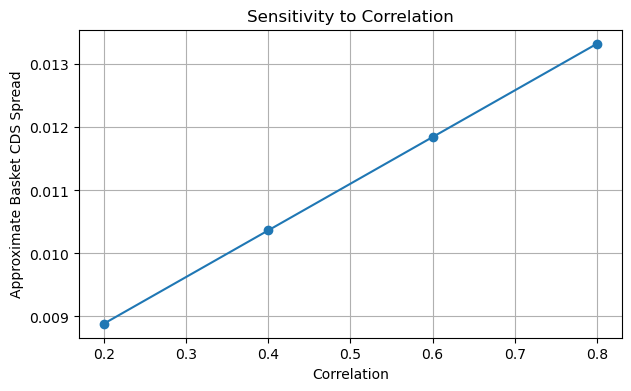

In [4]:
plt.figure(figsize=(7,4))

plt.plot(
    corr_results["Correlation"],
    corr_results["Approximate Spread"],
    marker="o"
)

plt.title("Sensitivity to Correlation")
plt.xlabel("Correlation")
plt.ylabel("Approximate Basket CDS Spread")

plt.grid(True)

plt.show()

## Step 4 Recovery Rate Sensitivity

The recovery rate determines the proportion of value recovered after default.

Lower recovery rates imply higher expected losses and therefore higher Basket CDS spreads.

In [5]:
recovery_levels = [0.20, 0.40, 0.60]

spread_recovery = []

for recovery in recovery_levels:
    spread = hazard_rates.mean() * (1 - recovery)
    spread_recovery.append(spread)

recovery_results = pd.DataFrame({
    "Recovery Rate": recovery_levels,
    "Approximate Spread": spread_recovery
})

recovery_results

,Recovery Rate,Approximate Spread
0,0.2,0.009872
1,0.4,0.007404
2,0.6,0.004936


## Step 5 Hazard Rate Sensitivity

Hazard rates represent the default intensity of the reference entities.

Higher hazard rates correspond to greater expected default risk and higher Basket CDS premiums.

In [6]:
shock = [-0.20, 0.00, 0.20]

spread_hazard = []

for s in shock:
    adjusted = hazard_rates.mean() * (1 + s)
    spread = adjusted * (1 - baseline_recovery)
    spread_hazard.append(spread)

hazard_results = pd.DataFrame({
    "Hazard Shock": [
        "-20%",
        "Baseline",
        "+20%"
    ],
    "Approximate Spread": spread_hazard
})

hazard_results

,Hazard Shock,Approximate Spread
0,-20%,0.005923
1,Baseline,0.007404
2,+20%,0.008885


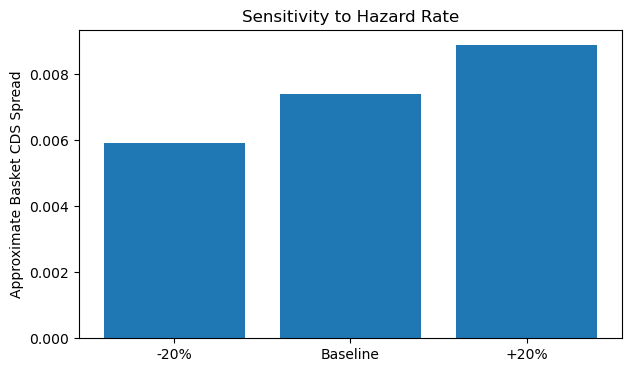

In [7]:
plt.figure(figsize=(7,4))

plt.bar(
    hazard_results["Hazard Shock"],
    hazard_results["Approximate Spread"]
)

plt.title("Sensitivity to Hazard Rate")

plt.ylabel("Approximate Basket CDS Spread")

plt.show()

# Business Interpretation

The sensitivity analysis demonstrates that Basket CDS pricing depends heavily on the underlying model assumptions.

Key observations include:

- Higher default correlation increases joint default risk.
- Lower recovery rates increase expected credit losses.
- Higher hazard rates result in higher Basket CDS premiums.

These findings highlight the importance of stress testing and validating model assumptions before applying the pricing model in practice.

# Key Takeaways

- Correlation is a major driver of Basket CDS valuation.
- Recovery assumptions significantly affect expected losses.
- Hazard rate estimation directly impacts model outputs.
- Sensitivity analysis provides confidence in model robustness.

# Summary

In this notebook we:

- Evaluated correlation sensitivity
- Evaluated recovery rate sensitivity
- Evaluated hazard rate sensitivity
- Interpreted the impact of key assumptions on Basket CDS pricing

This notebook completes the end-to-end Basket CDS pricing framework developed in this project.

The completed workflow includes:

- Data Collection
- Default Probability Estimation
- Correlation Estimation
- Gaussian Copula Simulation
- Basket CDS Pricing
- Model Validation and Sensitivity Analysis

Overall, the model behaves consistently with financial intuition, suggesting that the implementation provides a reasonable framework for educational Basket CDS pricing and further model enhancement.